In [14]:
import yfinance as yf
CAPMAN = yf.Ticker("CAPMAN.HE")
import pandas as pd
df = pd.DataFrame([CAPMAN.info])
CAPMAN.info
df["symbol"] = ["CAPMAN.HE"] 
df_small = df[['symbol','currentPrice', 'beta', 'trailingPE','priceToBook','bookValue','trailingEps','quickRatio','currentRatio','returnOnEquity','freeCashflow','revenueGrowth']]
df_small

,symbol,currentPrice,beta,trailingPE,priceToBook,bookValue,trailingEps,quickRatio,currentRatio,returnOnEquity,freeCashflow,revenueGrowth
0,CAPMAN.HE,1.774,0.49,25.342857,1.734115,1.023,0.07,2.501,2.501,0.07961,9875,0.252


In [15]:
import numpy as np

In [16]:
CAPMAN.info

{'address1': 'Ludviginkatu 6',
 'address2': '4th Floor',
 'city': 'Helsinki',
 'zip': '00130',
 'country': 'Finland',
 'website': 'https://www.capman.com',
 'industry': 'Asset Management',
 'industryKey': 'asset-management',
 'industryDisp': 'Asset Management',
 'sector': 'Financial Services',
 'sectorKey': 'financial-services',
 'sectorDisp': 'Financial Services',
 'longBusinessSummary': "CapMan Oyj is a leading Nordic private assets management and investment firm with an active approach to value creation. It is a private equity and venture capital firm specializing in growth capital investments, procurement, fund management, industry consolidation, special situations, turnaround, recapitalization, middle market buyouts, and credit and mezzanine financing in unquoted companies. The firm is sector agnostic and focuses on real estate, transportation, software, technology infrastructure assets, real asset debt, natural capital, telecommunications infrastructure, and investments in small 

In [17]:
analyytikko = CAPMAN.analyst_price_targets
analyytikko

{'current': 1.774, 'high': 2.1, 'low': 1.8, 'mean': 1.95, 'median': 1.95}

In [18]:
df = yf.download("CAPMAN.HE", period="6mo", interval="1d",
                 auto_adjust=True, progress=False)

close = df["Close"]
if isinstance(close, pd.DataFrame):   # varalta jos tulee ticker-taso
    close = close.iloc[:, 0]

r = np.log(close).diff().dropna()

vol_60  = float(r.tail(60).std() * np.sqrt(252))   # <-- tallennettu
vol_252 = float(r.tail(252).std() * np.sqrt(252))  # <-- optional

print("Viimeisten 60 päivän annualisoitu vola:", vol_60)
print("Viimeisten 252 päivän annualisoitu vola:", vol_252)

Viimeisten 60 päivän annualisoitu vola: 0.19285595653640522
Viimeisten 252 päivän annualisoitu vola: 0.2122981882829397


In [19]:
tuloslaskelma = CAPMAN.get_income_stmt()
tuloslaskelma

,2025-12-31,2024-12-31,2023-12-31,2022-12-31,2021-12-31
TaxEffectOfUnusualItems,0.000000e+00,0.000000e+00,0.000000e+00,-3.594357e+05,NaN
TaxRateForCalcs,7.611000e-02,2.393000e-01,3.208250e-01,1.382440e-01,NaN
NormalizedEBITDA,2.656600e+07,2.075000e+07,4.147000e+06,5.646300e+07,NaN
TotalUnusualItems,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.0
TotalUnusualItemsExcludingGoodwill,NaN,0.000000e+00,0.000000e+00,-2.600000e+06,0.0
NetIncomeFromContinuingOperationNetMinorityInterest,1.318200e+07,4.492000e+06,-3.331000e+06,3.961600e+07,NaN
ReconciledDepreciation,3.035000e+06,2.535000e+06,1.491000e+06,4.180000e+06,NaN
ReconciledCostOfRevenue,3.242700e+07,2.797900e+07,2.646200e+07,2.815500e+07,NaN
EBITDA,2.656600e+07,2.075000e+07,4.147000e+06,5.646300e+07,NaN
EBIT,2.353100e+07,1.821500e+07,2.656000e+06,5.228300e+07,NaN


In [20]:
tase = CAPMAN.balance_sheet
tase

,2025-12-31,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Treasury Shares Number,26299.0,26299.0,26299.0,26299.0,NaN
Ordinary Shares Number,176851911.0,176851911.0,158823088.0,158028669.0,NaN
Share Issued,176878210.0,176878210.0,158849387.0,158054968.0,NaN
Net Debt,38747000.0,9465000.0,50796000.0,36131000.0,NaN
Total Debt,106142000.0,102533000.0,93856000.0,92966000.0,NaN
...,...,...,...,...,...
Cash Cash Equivalents And Short Term Investments,64500000.0,93932000.0,39292000.0,53636000.0,NaN
Other Short Term Investments,3529000.0,3790000.0,275000.0,65000.0,NaN
Cash And Cash Equivalents,60971000.0,90142000.0,39017000.0,53571000.0,NaN
Cash Equivalents,10254000.0,11386000.0,872000.0,NaN,NaN


In [21]:
rahavirtalaskelma = CAPMAN.cashflow
rahavirtalaskelma

,2025-12-31,2024-12-31,2023-12-31,2022-12-31,2021-12-31
Free Cash Flow,11022000.0,10387000.0,5523000.0,28391000.0,NaN
Repurchase Of Capital Stock,-365000.0,-833000.0,-175000.0,0.0,NaN
Repayment Of Debt,0.0,-15000000.0,0.0,0.0,NaN
Issuance Of Capital Stock,-160000.0,0.0,442000.0,359000.0,NaN
Capital Expenditure,-607000.0,-123000.0,-871000.0,NaN,-360000.0
End Cash Position,10685000.0,19623000.0,38302000.0,46817000.0,NaN
Other Cash Adjustment Outside Changein Cash,NaN,-1000.0,NaN,1000.0,NaN
Beginning Cash Position,19623000.0,38302000.0,46817000.0,53255000.0,NaN
Changes In Cash,-8938000.0,-18678000.0,-8515000.0,-6438000.0,NaN
Financing Cash Flow,-17018000.0,-45404000.0,-19510000.0,-33515000.0,NaN


In [22]:
hinta1 = CAPMAN.history(period="8y", interval="1mo")

# 1) Poista tz indeksistä (yleisin syy)
if isinstance(hinta1.index, pd.DatetimeIndex) and hinta1.index.tz is not None:
    hinta1 = hinta1.copy()
    hinta1.index = hinta1.index.tz_localize(None)

hinta1.index.name = "Date"
display(hinta1.tail(24))

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2024-08-01,1.644595,1.674496,1.517952,1.621729,1901503,0.00,0.0
2024-09-01,1.658754,1.674946,1.570599,1.646161,1574459,0.04,0.0
2024-10-01,1.655156,1.737914,1.602983,1.620974,2268840,0.00,0.0
2024-11-01,1.628170,1.665951,1.502234,1.593987,2891295,0.00,0.0
2024-12-01,1.593987,1.608380,1.500435,1.541814,3042717,0.00,0.0
2025-01-01,1.541814,1.635366,1.529220,1.574197,1520810,0.00,0.0
2025-02-01,1.558006,1.799083,1.529220,1.739713,2041307,0.00,0.0
2025-03-01,1.811322,1.910087,1.710693,1.714420,2670249,0.07,0.0
2025-04-01,1.733055,1.787096,1.472165,1.747963,2497073,0.00,0.0


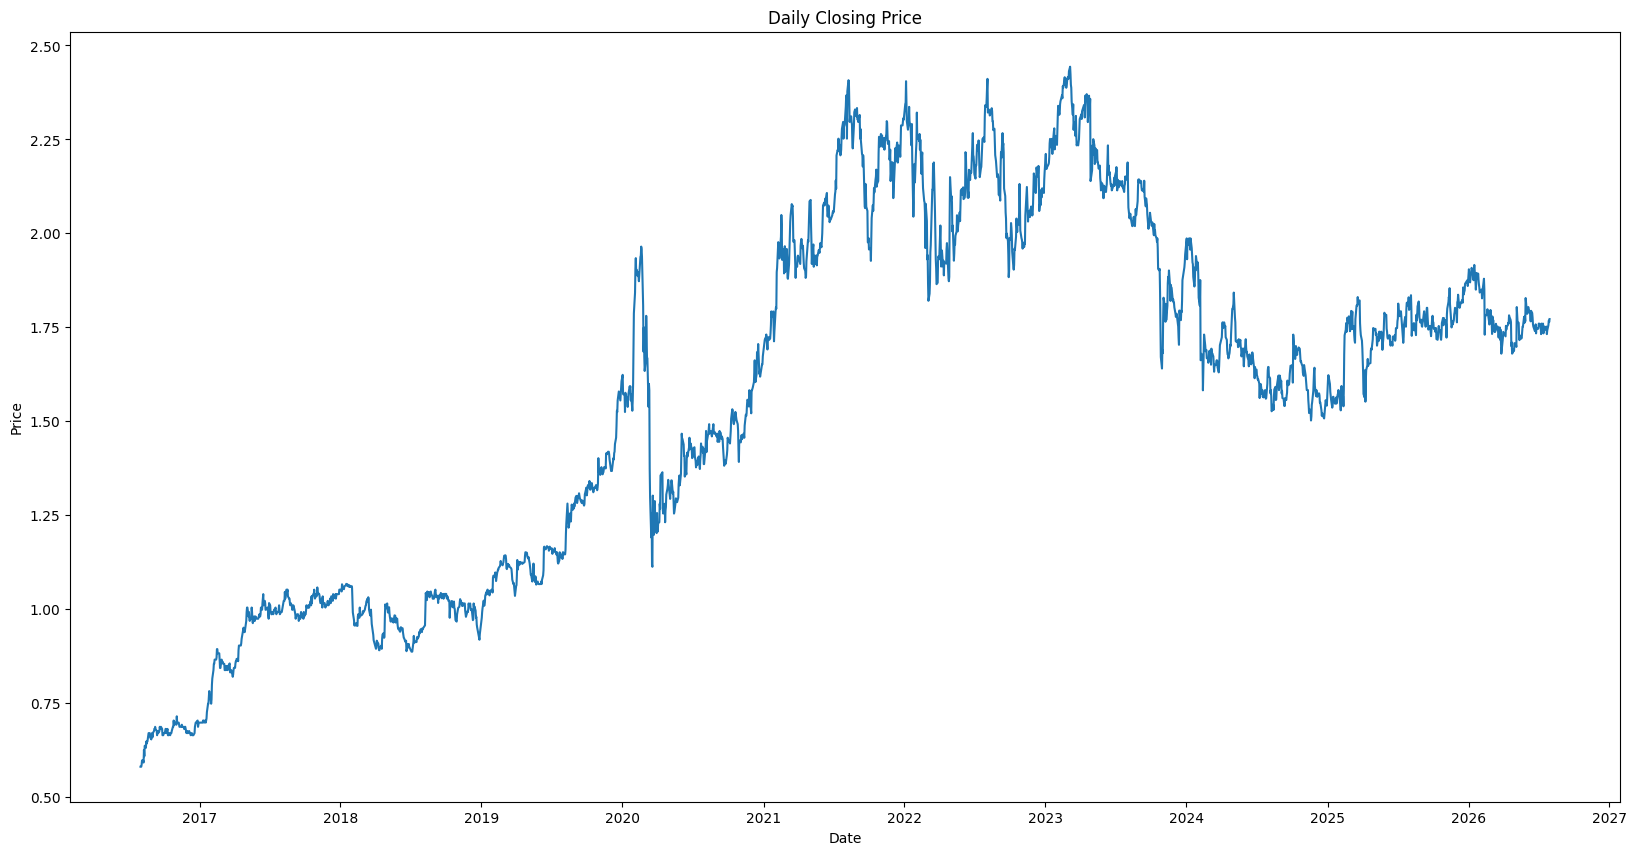

In [23]:
import matplotlib.pyplot as plt
hinta = CAPMAN.history(period="10y", interval = "1d")
plt.figure(figsize=(20, 10))
plt.plot(hinta.index, hinta['Close'])
plt.title('Daily Closing Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.savefig("Hinta.png")

In [24]:
#Viimeisen 2 vuoden ROE
inc = CAPMAN.income_stmt      # annual
bs  = CAPMAN.balance_sheet    # annual

try:
    net_income = inc.loc["Net Income"]
except:
    net_income = inc.loc["Net Income Common Stockholders"]

try:
    equity = bs.loc["Total Stockholder Equity"]
except:
    equity = bs.loc["Stockholders Equity"]

cols = list(set(inc.columns).intersection(set(bs.columns)))
cols.sort(reverse=True)

y0, y1, y2 = cols[0], cols[1], cols[2]

avg_equity_y0 = (equity[y0] + equity[y1]) / 2
avg_equity_y1 = (equity[y1] + equity[y2]) / 2

roe_y0 = net_income[y0] / avg_equity_y0
roe_y1 = net_income[y1] / avg_equity_y1
roe_2y_avg = (roe_y0 + roe_y1) / 2  # <-- lisää tämä

print("Fiscal year end:", y0, "ROE:", roe_y0)
print("Fiscal year end:", y1, "ROE:", roe_y1)
print("2y average ROE:", roe_2y_avg)

print("ROE %:", roe_y0 * 100, roe_y1 * 100)
print("2y avg %:", roe_2y_avg * 100)

Fiscal year end: 2025-12-31 00:00:00 ROE: 0.06814463287350439
Fiscal year end: 2024-12-31 00:00:00 ROE: 0.4395846020705792
2y average ROE: 0.2538646174720418
ROE %: 6.814463287350439 43.95846020705792
2y avg %: 25.38646174720418


In [25]:
metrics = pd.DataFrame({
    "Metric": [
        "ROE (latest FY)",
        "ROE (prev FY)",
        "ROE 2y average",
        "Volatility 60d (ann.)",
        "Volatility 252d (ann.)"
    ],
    "Value": [
        float(roe_y0),
        float(roe_y1),
        float(roe_2y_avg),
        float(vol_60),
        float(vol_252)
    ],
})

# prosenttina helpompi luettava
metrics["Value_%"] = metrics["Value"] * 100

with pd.ExcelWriter("CAPMAN.xlsx", engine="openpyxl") as writer:
    # 1) Yhteenveto ylös
    df_small.to_excel(writer, sheet_name="Yhteenveto", index=False)

    # 2) metrics alle (2 tyhjää riviä väliin)
    startrow = len(df_small) + 3
    metrics.to_excel(writer, sheet_name="Yhteenveto", index=False, startrow=startrow)

    # muut sheetit normaalisti
    tuloslaskelma.to_excel(writer, sheet_name="Tuloslaskelma")
    tase.to_excel(writer, sheet_name="Tase")
    rahavirtalaskelma.to_excel(writer, sheet_name="Rahavirtalaskelma")
    hinta1.to_excel(writer, sheet_name="Hinta")

In [26]:
cap = yf.download("CAPMAN.HE", period="5y", interval="1mo", auto_adjust=True, progress=False)["Close"]

# Kokeile useampi Helsingin indeksi/ETF, koska kaikilla ei ole dataa Yahoo:ssa
candidates = ["^OMXHPI", "^OMXH25", "OMXHPI.HE", "OMXH25.HE", "HEL.HE"]
mkt = None
used = None
for t in candidates:
    s = yf.download(t, period="5y", interval="1mo", auto_adjust=True, progress=False)
    if not s.empty and "Close" in s.columns and s["Close"].dropna().shape[0] > 10:
        mkt = s["Close"]
        used = t
        break

print("CAPMAN rows:", cap.dropna().shape[0])
print("Market ticker used:", used)
print("Market rows:", None if mkt is None else mkt.dropna().shape[0])

# 2) Yhdistä ja varmista ettei tule tyhjää
df = pd.concat([cap, mkt], axis=1)
df.columns = ["CAPMAN", "mkt"]
df = df.dropna()
print("Common rows after dropna:", df.shape[0])

# 3) Laske tuotot ja beta
r = np.log(df).diff().dropna()
print("Return rows:", r.shape[0])

if r.shape[0] < 12:
    raise ValueError("Liian vähän datapisteitä betan laskuun. Markkinaticker ei toimi tai data ei kohtaa.")

beta = np.cov(r["CAPMAN"], r["mkt"], ddof=1)[0,1] / np.var(r["mkt"], ddof=1)
print("Beta:", beta)

Taaleri rows: 60
Market ticker used: ^OMXH25
Market rows: 60
Common rows after dropna: 60
Return rows: 59
Beta: 0.6104878210516916


In [29]:
import yfinance as yf
import pandas as pd

CAPMAN = yf.Ticker("CAPMAN.HE")
MARKET = yf.Ticker("^OMXHGI")

capman = CAPMAN.history(
    period="2y",
    interval="1d",
    auto_adjust=False
)[["Close"]].rename(columns={"Close": "CapMan Close"})

market = MARKET.history(
    period="2y",
    interval="1d",
    auto_adjust=False
)[["Close"]].rename(columns={"Close": "Market Close"})


# Muutetaan indeksit tavallisiksi päivämääriksi
capman = capman.reset_index()
market = market.reset_index()

capman["Date"] = pd.to_datetime(capman["Date"]).dt.date
market["Date"] = pd.to_datetime(market["Date"]).dt.date


# Yhdistetään kalenteripäivän perusteella
prices = pd.merge(
    capman[["Date", "CapMan Close"]],
    market[["Date", "Market Close"]],
    on="Date",
    how="inner"
)

prices["Date"] = pd.to_datetime(prices["Date"])
prices = prices.set_index("Date")


# Viikon viimeinen saatavilla oleva päätöskurssi
weekly_prices = (
    prices
    .resample("W-FRI")
    .last()
    .dropna()
)

weekly_prices
pd.set_option("display.max_rows", None)

weekly_prices

    


,CapMan Close,Market Close
Date,,
2024-08-02,1.842,30770.410156
2024-08-09,1.736,31031.359375
2024-08-16,1.802,31675.500000
2024-08-23,1.816,32266.369141
2024-08-30,1.844,32658.310547
2024-09-06,1.776,31509.580078
2024-09-13,1.776,31485.980469
2024-09-20,1.774,31821.580078
2024-09-27,1.832,33010.371094
